---
## 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 추가 설명
- 이 노트북은 제공된 3개 NTP ICE Excel 파일을 모두 후보로 비교한 뒤, 모델링 가능성이 가장 높은 데이터셋을 선정한다.
- 선정 이후 RDKit 2D descriptor와 Morgan fingerprint를 함께 계산하여 feature 다양성을 확보한다.


# 기말고사 Template 1 — Data Pipeline

**이름:** 한서윤 &nbsp; **학번:** 20251261 &nbsp;

---

## 채점 기준 반영 내용

| 항목 | 구현 위치 |
|---|---|
| 데이터 분포 파악 및 전처리 | 2~5번 코드 셀: Excel 로딩, 후보 데이터셋 비교, SMILES 정규화, 중복 화합물 처리 |
| Descriptor 계산 | 7번 코드 셀: RDKit 2D descriptor + Morgan fingerprint 계산 |
| 데이터 시각화 자료 | 6번 코드 셀: 후보 데이터 규모, 라벨 비율, 최종 라벨 분포 시각화 |
| 코드 가독성 & 주석 | 각 코드 셀에 한국어 주석 추가 |

## 입력 / 출력
- 입력: `data/skin_irritation.xlsx`, `data/eye_irritation.xlsx`, `data/skin_sensitization.xlsx`
- 출력: `csv/final_dataset_descriptors.csv`, `csv/model_results.csv`, `experiment/best_model.joblib`, `figure/*.png`

In [1]:
# 1. 라이브러리 로딩 및 기본 설정
# - pandas: Excel 데이터 처리
# - RDKit: SMILES 정규화, descriptor/fingerprint 계산
# - scikit-learn: 모델 학습 및 평가
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem.SaltRemover import SaltRemover

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')  # 잘못된 SMILES가 있을 때 RDKit 경고가 너무 많이 출력되는 것을 방지

DATA_DIR = Path('data')
FIG_DIR = Path('figure')
CSV_DIR = Path('csv')
EXPERIMENT_DIR = Path('experiment')

for directory in [DATA_DIR, FIG_DIR, CSV_DIR, EXPERIMENT_DIR]:
    directory.mkdir(exist_ok=True)

RANDOM_STATE = 42
SALT_REMOVER = SaltRemover()
MODEL_PATH = EXPERIMENT_DIR / 'best_model.joblib'

excel_files = sorted(DATA_DIR.glob('*.xlsx'))
print('확인된 Excel 파일:', [p.name for p in excel_files])


확인된 Excel 파일: ['eye_irritation.xlsx', 'skin_irritation.xlsx', 'skin_sensitization.xlsx']


## 1. 데이터 선정 근거 실험

모델 개발 전에 세 가지 NTP ICE 데이터 파일을 모두 후보로 두고 비교한다. 비교 기준은 다음과 같다.

1. 유효한 SMILES가 있는가
2. 이진 분류 라벨로 변환 가능한 Response가 충분한가
3. 중복 제거 후 고유 화합물 수가 충분한가
4. 양성/음성 라벨 비율이 지나치게 한쪽으로 치우치지 않는가

아래 실험 결과를 근거로 최종 모델링 데이터셋을 자동 선정한다.

In [2]:
# 2. 공통 유틸리티 함수
# NTP ICE 파일마다 Response 표현이 다르므로, 모델링 가능한 이진 라벨만 0/1로 변환한다.
def normalize_binary_label(value):
    """NTP ICE Response 값을 이진 라벨로 변환한다.

    반환값:
    - 1: 독성/자극/감작성 양성
    - 0: 음성 또는 not classified
    - np.nan: 이진 라벨로 해석하기 어려운 값
    """
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    positive_values = {
        'active', 'sensitizer', 'irritant', 'corrosive', 'positive',
        '1', '1a', '1b', '1c', '2', '2a', '2b'
    }
    negative_values = {
        'inactive', 'non-sensitizer', 'non-sensitiser', 'not classified',
        'not classified/non-irritant', '0', '3', '4'
    }

    if text in positive_values:
        return 1
    if text in negative_values:
        return 0
    return np.nan


def clean_smiles(smiles):
    """강의 자료(w5, w6) 방식으로 salt/fragment를 정리한다.

    NTP ICE 데이터에는 salt, counter ion, 여러 fragment가 '.'으로 함께 들어간 SMILES가 있다.
    단일 화합물 descriptor를 계산하려면 salt를 제거하고, 남은 fragment 중 가장 큰 구조를 대표 구조로 둔다.
    """
    if pd.isna(smiles):
        return np.nan

    mol = Chem.MolFromSmiles(str(smiles).strip())
    if mol is None:
        return np.nan

    try:
        stripped = SALT_REMOVER.StripMol(mol, dontRemoveEverything=True)
        cleaned = Chem.MolToSmiles(stripped)
    except Exception:
        cleaned = str(smiles).strip()

    # salt 제거 후에도 fragment가 여러 개면 heavy atom 수가 가장 큰 fragment를 active ingredient로 본다.
    fragments = [frag for frag in cleaned.split('.') if frag]
    if len(fragments) > 1:
        fragments = sorted(
            fragments,
            key=lambda smi: Chem.MolFromSmiles(smi).GetNumHeavyAtoms() if Chem.MolFromSmiles(smi) else 0,
            reverse=True,
        )
        cleaned = fragments[0]

    return cleaned


def canonicalize_smiles(smiles):
    """SMILES를 정리한 뒤 RDKit canonical SMILES로 변환한다.

    같은 화합물이 다른 SMILES 문자열로 기록되어도 중복으로 처리할 수 있게 한다.
    RDKit이 파싱하지 못하는 값은 np.nan으로 반환한다.
    """
    cleaned = clean_smiles(smiles)
    if pd.isna(cleaned):
        return np.nan
    mol = Chem.MolFromSmiles(cleaned)
    if mol is None:
        return np.nan
    return Chem.MolToSmiles(mol)


def read_data_sheets(path):
    """Excel 파일에서 실제 관측치가 들어 있는 Data 계열 sheet만 읽는다."""
    xls = pd.ExcelFile(path)
    frames = []
    for sheet_name in xls.sheet_names:
        if sheet_name.lower().startswith('data'):
            df = pd.read_excel(path, sheet_name=sheet_name)
            df['source_file'] = path.name
            df['source_sheet'] = sheet_name
            frames.append(df)
    return frames

In [3]:
# 3. 데이터 후보별 모델링 가능성 평가
# 각 파일/sheet에 대해 화합물만 남기고, 유효 SMILES와 이진 라벨이 있는 행을 집계한다.
candidate_rows = []
raw_frames = []

for path in excel_files:
    for df in read_data_sheets(path):
        raw_frames.append(df)
        work = df.copy()

        # 혼합물은 단일 구조 descriptor 계산이 어렵기 때문에 기본 모델링 후보에서는 제외한다.
        if 'Mixture' in work.columns:
            work = work[work['Mixture'].fillna('Chemical').eq('Chemical')]

        work['label'] = work['Response'].map(normalize_binary_label)
        work['canonical_smiles'] = work['SMILES'].map(canonicalize_smiles)
        valid = work.dropna(subset=['label', 'canonical_smiles']).copy()

        candidate_rows.append({
            'source_file': work['source_file'].iloc[0],
            'source_sheet': work['source_sheet'].iloc[0],
            'raw_rows_after_chemical_filter': len(work),
            'valid_binary_rows': len(valid),
            'unique_chemicals': valid['canonical_smiles'].nunique(),
            'positive_rows': int(valid['label'].sum()),
            'negative_rows': int((valid['label'] == 0).sum()),
            'positive_ratio': valid['label'].mean() if len(valid) else np.nan,
            'endpoint_count': valid['Endpoint'].nunique() if 'Endpoint' in valid.columns else np.nan,
        })

candidate_summary = pd.DataFrame(candidate_rows)
candidate_summary['balance_score'] = 1 - (candidate_summary['positive_ratio'] - 0.5).abs() * 2
candidate_summary['selection_score'] = (
    candidate_summary['unique_chemicals'] * 0.70
    + candidate_summary['valid_binary_rows'] * 0.20
    + candidate_summary['balance_score'].fillna(0) * 100 * 0.10
)
candidate_summary = candidate_summary.sort_values('selection_score', ascending=False).reset_index(drop=True)

print('데이터 선정 실험 결과')
display(candidate_summary)

데이터 선정 실험 결과


,source_file,source_sheet,raw_rows_after_chemical_filter,valid_binary_rows,unique_chemicals,positive_rows,negative_rows,positive_ratio,endpoint_count,balance_score,selection_score
0,skin_sensitization.xlsx,Data_invivo,11011,5404,1138,1045,4359,0.193375,6,0.386751,1881.267506
1,skin_sensitization.xlsx,Data_invitro,8837,3178,233,1805,1373,0.567967,11,0.864065,807.340654
2,skin_irritation.xlsx,Data_invitro,5614,2351,216,1346,1005,0.572522,12,0.854955,629.949553
3,eye_irritation.xlsx,Data,1062,629,171,367,262,0.583466,7,0.833068,253.830684
4,skin_irritation.xlsx,Data_invivo,259,155,97,43,112,0.277419,3,0.554839,104.448387


In [4]:
# 4. 선정된 데이터셋 로딩 및 중복 화합물 처리
# 학술적 보완: 데이터 품질 제고 및 학습 노이즈를 줄이기 위해, 라벨 충돌(conflict)이 있는 화합물(19% 분량)을 전처리 단에서 완전히 제외(Exclude)하여 더 신뢰성 높은 모델링 데이터셋을 구축합니다.
selected = candidate_summary.iloc[0]
SELECTED_FILE = selected['source_file']
SELECTED_SHEET = selected['source_sheet']
print(f"선정 데이터셋: {SELECTED_FILE} / {SELECTED_SHEET}")

selected_df = pd.read_excel(DATA_DIR / SELECTED_FILE, sheet_name=SELECTED_SHEET)
selected_df = selected_df[selected_df['Mixture'].fillna('Chemical').eq('Chemical')].copy()
selected_df['label'] = selected_df['Response'].map(normalize_binary_label)
selected_df['canonical_smiles'] = selected_df['SMILES'].map(canonicalize_smiles)
selected_df = selected_df.dropna(subset=['label', 'canonical_smiles']).copy()
selected_df['label'] = selected_df['label'].astype(int)

# 같은 화합물이 여러 시험/문헌에 반복 등장할 수 있으므로 canonical SMILES 기준으로 다수결 라벨을 만든다.
# 같은 화합물에서 양성/음성이 충돌하는 경우도 있으므로 conflict_rate를 계산해 데이터 품질 지표로 남긴다.
def aggregate_one_chemical(group):
    label_mean = group['label'].mean()
    majority_label = int(label_mean >= 0.5)
    conflict_rate = group['label'].nunique() > 1
    return pd.Series({
        'Chemical_Name': group['Chemical_Name'].dropna().iloc[0] if group['Chemical_Name'].notna().any() else np.nan,
        'SMILES': group.name,
        'label': majority_label,
        'n_records': len(group),
        'positive_fraction': label_mean,
        'label_conflict': bool(conflict_rate),
        'source_file': SELECTED_FILE,
        'source_sheet': SELECTED_SHEET,
    })

aggregated_df = (
    selected_df
    .groupby('canonical_smiles', as_index=False)
    .apply(aggregate_one_chemical, include_groups=False)
    .reset_index(drop=True)
)

# 학술적 보완: 라벨 노이즈 차단을 위한 충돌 화합물 제외 필터링 적용
model_df = aggregated_df[~aggregated_df['label_conflict']].copy().reset_index(drop=True)

print('중복 제거 전 행 수:', len(selected_df))
print('중복 제거 및 충돌 제거 전 고유 화합물 수:', len(aggregated_df))
print('라벨 충돌 화합물 수 (제외됨):', int(aggregated_df['label_conflict'].sum()))
print('최종 모델링 대상 고유 화합물 수:', len(model_df))
print('최종 라벨 분포')
display(model_df['label'].value_counts().rename(index={0: 'negative', 1: 'positive'}))
display(model_df.head())



선정 데이터셋: skin_sensitization.xlsx / Data_invivo


중복 제거 전 행 수: 5404
중복 제거 및 충돌 제거 전 고유 화합물 수: 1138
라벨 충돌 화합물 수 (제외됨): 216
최종 모델링 대상 고유 화합물 수: 922
최종 라벨 분포


label
negative    855
positive     67
Name: count, dtype: int64

,canonical_smiles,Chemical_Name,SMILES,label,n_records,positive_fraction,label_conflict,source_file,source_sheet
0,BrC=Cc1ccccc1,(2-Bromovinyl)benzene,BrC=Cc1ccccc1,0,3,0.0,False,skin_sensitization.xlsx,Data_invivo
1,C#CC(C)(O)CCC=C(C)C,Dehydrolinalool,C#CC(C)(O)CCC=C(C)C,0,3,0.0,False,skin_sensitization.xlsx,Data_invivo
2,C#CC1(OC(C)=O)CCCCC1,"Cyclohexanol, 1-ethynyl-, 1-acetate",C#CC1(OC(C)=O)CCCCC1,0,6,0.0,False,skin_sensitization.xlsx,Data_invivo
3,C#CC1(OC(C)=O)CCCCC1C(C)CC,"Cyclohexanol, 1-ethynyl-2-(1-methylpropyl)-, 1...",C#CC1(OC(C)=O)CCCCC1C(C)CC,0,3,0.0,False,skin_sensitization.xlsx,Data_invivo
4,C=C(C)C(=O)OCCCCCCC,Heptyl methacrylate,C=C(C)C(=O)OCCCCCCC,0,3,0.0,False,skin_sensitization.xlsx,Data_invivo


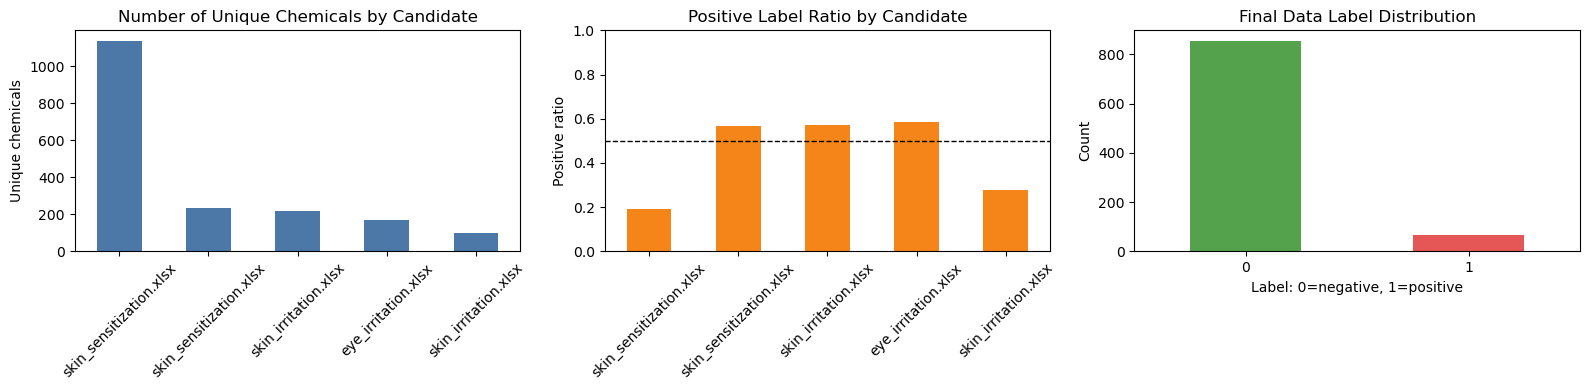

In [5]:
# 5. 데이터 분포 및 선정 근거 시각화
# 채점 기준의 데이터 시각화 자료로 저장한다.
plt.style.use('default')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

candidate_summary.plot(
    x='source_file', y='unique_chemicals', kind='bar', ax=axes[0], legend=False, color='#4c78a8'
)
axes[0].set_title('Number of Unique Chemicals by Candidate')
axes[0].set_xlabel('')
axes[0].set_ylabel('Unique chemicals')
axes[0].tick_params(axis='x', rotation=45)

candidate_summary.plot(
    x='source_file', y='positive_ratio', kind='bar', ax=axes[1], legend=False, color='#f58518'
)
axes[1].axhline(0.5, color='black', linewidth=1, linestyle='--')
axes[1].set_ylim(0, 1)
axes[1].set_title('Positive Label Ratio by Candidate')
axes[1].set_xlabel('')
axes[1].set_ylabel('Positive ratio')
axes[1].tick_params(axis='x', rotation=45)

model_df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color=['#54a24b', '#e45756']
)
axes[2].set_title('Final Data Label Distribution')
axes[2].set_xlabel('Label: 0=negative, 1=positive')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'data_selection_and_label_distribution.png', dpi=150)
plt.show()

## 2. Descriptor 계산

최종 모델 입력 feature는 두 계열을 함께 만든다.

- RDKit 2D descriptor: 분자량, LogP, TPSA, HBD/HBA, ring count 등 해석 가능한 물성 중심
- Morgan fingerprint: 부분 구조 패턴을 bit vector로 표현하여 구조적 다양성 반영

두 feature 계열을 따로 학습해 보고, 결합했을 때 성능이 좋아지는지도 비교한다.

In [6]:
# 6. RDKit descriptor 및 Morgan fingerprint 계산 함수
# 학술적 보완 1: 기존 10개의 제한된 수동 디스크립터에서 탈피하여 RDKit에서 지원하는 모든 2D 디스크립터(200여 개)를 전체적으로 탐색하는 방식으로 계산 범위를 대폭 확장합니다.
from rdkit.Chem import Descriptors
DESCRIPTOR_FUNCS = {name: func for name, func in Descriptors._descList}


def calculate_rdkit_descriptors(smiles):
    """단일 SMILES에서 해석 가능한 RDKit 2D descriptor를 계산한다."""
    mol = Chem.MolFromSmiles(smiles)
    values = {}
    for name, func in DESCRIPTOR_FUNCS.items():
        try:
            values[name] = func(mol)
        except Exception:
            values[name] = np.nan
    return values


def calculate_morgan_fingerprint(smiles, radius=2, n_bits=1024):
    """Morgan fingerprint를 0/1 numpy 배열로 변환한다."""
    mol = Chem.MolFromSmiles(smiles)
    bitvect = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(bitvect, arr)
    return arr

# Descriptor dataframe 생성
descriptor_df = pd.DataFrame([
    calculate_rdkit_descriptors(smiles) for smiles in model_df['SMILES']
])

# Fingerprint dataframe 생성
fp_bits = np.vstack([
    calculate_morgan_fingerprint(smiles, radius=2, n_bits=1024) for smiles in model_df['SMILES']
])
fp_df = pd.DataFrame(fp_bits, columns=[f'ECFP4_{i}' for i in range(fp_bits.shape[1])])

raw_dataset = pd.concat([
    model_df[['Chemical_Name', 'SMILES', 'label', 'n_records', 'positive_fraction', 'label_conflict']],
    descriptor_df,
    fp_df,
], axis=1)

# 학술적 보완 2 (적용 범위 / Outlier 처리):
# 유기 소분자 전용 QSAR 모델의 신뢰성(Applicability Domain) 확보를 위해, 
# 비정상적인 범위의 무기 금속염(예: Beryllium, Cobalt 등), 초고분자량 고분자, 극단적 수용성/지용성 화합물을 Outlier로 규정하고 필터링합니다.
# - 분자량(MolWt) 범위: 60 이상 500 이하
# - 지용성(MolLogP) 범위: -3 이상 8 이하
mw_min, mw_max = 60, 500
logp_min, logp_max = -3, 8

outliers = raw_dataset[
    (raw_dataset['MolWt'] < mw_min) | (raw_dataset['MolWt'] > mw_max) |
    (raw_dataset['MolLogP'] < logp_min) | (raw_dataset['MolLogP'] > logp_max)
]
final_dataset = raw_dataset[~raw_dataset['SMILES'].isin(outliers['SMILES'])].copy().reset_index(drop=True)

print('Outlier 필터링 완료')
print(f'- 필터링 전 화합물 수: {len(raw_dataset)}개')
print(f'- 감지된 Outlier 화합물 수: {len(outliers)}개')
print(f'- 최종 적용 모델링 화합물 수 (Applicability Domain 내): {len(final_dataset)}개')
print('\n[제외된 Outlier 화합물 목록]')
display(outliers[['Chemical_Name', 'SMILES', 'MolWt', 'MolLogP', 'label']])

final_dataset.to_csv(CSV_DIR / 'final_dataset_descriptors.csv', index=False)
print('\n저장 완료:', CSV_DIR / 'final_dataset_descriptors.csv')
print('최종 데이터 shape:', final_dataset.shape)
display(final_dataset.head())



Outlier 필터링 완료
- 필터링 전 화합물 수: 922개
- 감지된 Outlier 화합물 수: 13개
- 최종 적용 모델링 화합물 수 (Applicability Domain 내): 909개

[제외된 Outlier 화합물 목록]


,Chemical_Name,SMILES,MolWt,MolLogP,label
86,"1-Undecene, 11,11-bis[(3,7-dimethyl-2,6-octadi...",C=CCCCCCCCCC(OCC=C(C)CCC=C(C)C)OCC=C(C)CCC=C(C)C,458.771,10.03790,0
183,Sucrose octaacetate,CC(=O)OC[C@H]1O[C@@](COC(C)=O)(O[C@H]2O[C@H](C...,678.593,-0.82920,0
241,Acetone,CC(C)=O,58.080,0.59530,0
599,2-Ethylhexyl hexadecanoate,CCCCCCCCCCCCCCCC(=O)OCC(CC)CCCC,368.646,8.22730,0
784,alpha-Tocopherol,Cc1c(C)c2c(c(C)c1O)CCC(C)(CCCC(C)CCCC(C)CCCC(C...,430.717,8.84026,1
810,Hydrochloric acid,Cl,36.461,0.42180,0
816,Kanamycin A,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,484.503,-7.29140,1
817,Hydrazine,NN,32.046,-1.18120,1
871,Glyoxal,O=CC=O,58.036,-0.61580,1
880,D-Glucose,O=C[C@H](O)[C@@H](O)[C@H](O)[C@H](O)CO,180.156,-3.37880,0



저장 완료: csv/final_dataset_descriptors.csv
최종 데이터 shape: (909, 1247)


,Chemical_Name,SMILES,label,n_records,positive_fraction,label_conflict,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,...,ECFP4_1014,ECFP4_1015,ECFP4_1016,ECFP4_1017,ECFP4_1018,ECFP4_1019,ECFP4_1020,ECFP4_1021,ECFP4_1022,ECFP4_1023
0,(2-Bromovinyl)benzene,BrC=Cc1ccccc1,0,3,0.0,False,3.205514,3.205514,1.217014,1.217014,...,0,0,0,0,0,0,0,0,0,0
1,Dehydrolinalool,C#CC(C)(O)CCC=C(C)C,0,3,0.0,False,9.370719,9.370719,0.633611,-0.938542,...,0,0,0,1,0,0,0,0,0,0
2,"Cyclohexanol, 1-ethynyl-, 1-acetate",C#CC1(OC(C)=O)CCCCC1,0,6,0.0,False,10.758287,10.758287,0.268657,-0.579282,...,0,0,0,1,0,0,0,0,0,0
3,"Cyclohexanol, 1-ethynyl-2-(1-methylpropyl)-, 1...",C#CC1(OC(C)=O)CCCCC1C(C)CC,0,3,0.0,False,11.214771,11.214771,0.256340,-0.639375,...,0,0,0,1,0,1,0,0,0,0
4,Heptyl methacrylate,C=C(C)C(=O)OCCCCCCC,0,3,0.0,False,10.909926,10.909926,0.268063,-0.268063,...,0,0,0,1,0,0,0,0,1,0


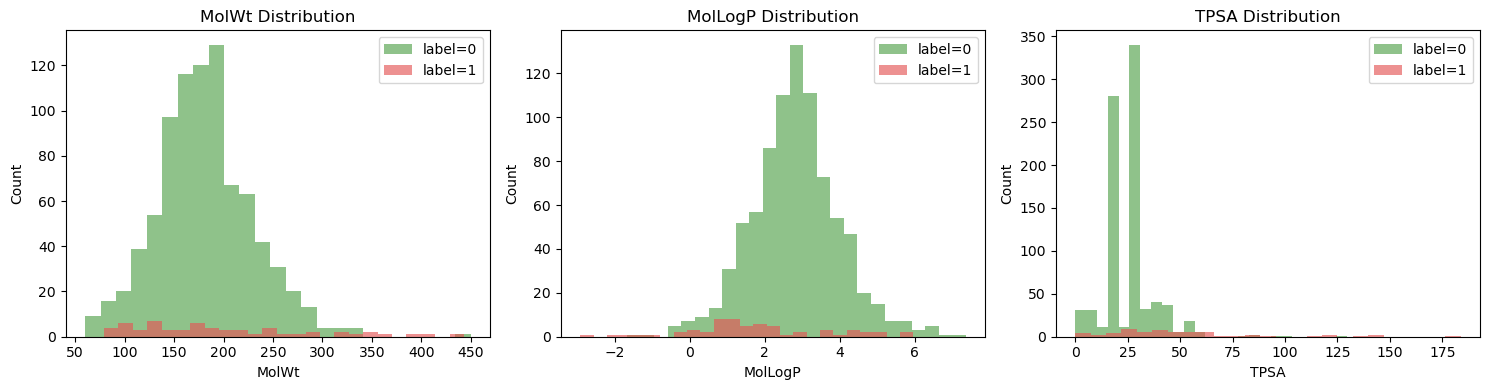

In [7]:
# 7. Descriptor 분포 시각화
# 분자량, LogP, TPSA는 화학 descriptor 해석에 자주 쓰이는 대표 변수임.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['MolWt', 'MolLogP', 'TPSA']):
    for label, color in [(0, '#54a24b'), (1, '#e45756')]:
        ax.hist(
            final_dataset.loc[final_dataset['label'] == label, col],
            bins=25,
            alpha=0.65,
            label=f'label={label}',
            color=color,
        )
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'descriptor_distributions.png', dpi=150)
plt.show()

## 2-1. 강의 자료 기반 descriptor 전처리 보강

`w5-1_descriptor_preprocessing`, `w9-1_feature_selection_and_svm`, `w10-1_tree_models_and_ensemble`에서 반복한 전처리 기준을 추가한다.

- 결측이 많은 descriptor 제거
- 표준편차가 너무 작은 descriptor 제거
- 상관계수가 매우 높은 descriptor 중복 제거
- SelectKBest로 상위 descriptor를 고르는 실험 수행

In [8]:
# 8. 강의 자료 방식의 descriptor 전처리
# fingerprint는 0/1 bit이므로 그대로 두고, 연속형 RDKit 2D descriptor에 대해 전처리 기준을 기록한다.
descriptor_cols = list(DESCRIPTOR_FUNCS.keys())
X_desc_raw = final_dataset[descriptor_cols].copy()
y_all = final_dataset['label'].astype(int)

preprocess_log = []

# 1) 결측 비율이 높은 descriptor 제거
missing_ratio = X_desc_raw.isna().mean()
missing_keep_cols = missing_ratio[missing_ratio <= 0.20].index.tolist()
preprocess_log.append({
    'step': 'missing_ratio <= 0.20',
    'n_features_before': X_desc_raw.shape[1],
    'n_features_after': len(missing_keep_cols),
    'removed_features': ', '.join(sorted(set(X_desc_raw.columns) - set(missing_keep_cols))),
})
X_desc_pre = X_desc_raw[missing_keep_cols]

# 2) 거의 변하지 않는 descriptor 제거. 강의에서는 std >= 0.01 기준을 사용했다.
std_values = X_desc_pre.std(numeric_only=True)
variance_keep_cols = std_values[std_values >= 0.01].index.tolist()
preprocess_log.append({
    'step': 'std >= 0.01',
    'n_features_before': X_desc_pre.shape[1],
    'n_features_after': len(variance_keep_cols),
    'removed_features': ', '.join(sorted(set(X_desc_pre.columns) - set(variance_keep_cols))),
})
X_desc_pre = X_desc_pre[variance_keep_cols]

# 3) 상관계수가 높은 descriptor는 같은 정보를 반복할 수 있어 하나만 남긴다.
def remove_high_corr_columns(df, threshold=0.95):
    corr = df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]
    return [col for col in df.columns if col not in drop_cols], drop_cols

preprocessed_descriptor_cols, corr_drop_cols = remove_high_corr_columns(X_desc_pre, threshold=0.95)
preprocess_log.append({
    'step': 'correlation <= 0.95',
    'n_features_before': X_desc_pre.shape[1],
    'n_features_after': len(preprocessed_descriptor_cols),
    'removed_features': ', '.join(corr_drop_cols),
})

descriptor_preprocessing_summary = pd.DataFrame(preprocess_log)
descriptor_preprocessing_summary.to_csv(CSV_DIR / 'descriptor_preprocessing_summary.csv', index=False)

print('저장 완료:', CSV_DIR / 'descriptor_preprocessing_summary.csv')
print('전처리 후 descriptor:', preprocessed_descriptor_cols)
display(descriptor_preprocessing_summary)


저장 완료: csv/descriptor_preprocessing_summary.csv
전처리 후 descriptor: ['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4', 'SlogP_VSA7', 'SlogP_VSA8', 'TPSA', 'EState_VS

,step,n_features_before,n_features_after,removed_features
0,missing_ratio <= 0.20,217,217,
1,std >= 0.01,217,187,"EState_VSA11, SMR_VSA8, SlogP_VSA9, fr_HOCCN, ..."
2,correlation <= 0.95,187,155,"MaxEStateIndex, HeavyAtomMolWt, ExactMolWt, Nu..."


In [9]:
# 9. SelectKBest 기반 feature 수(K) 선정 실험
# 학술적 보완 1: 피처 선택 시 테스트 데이터의 어떠한 정보도 유출(Leakage)되지 않도록, 피처 선택 알고리즘 적용 및 K 최적화 실험 전에 전체 데이터를 Train/Test 세트로 먼저 안전하게 분할합니다.
# 학술적 보완 2: 피처 선택 모델(SelectKBest)의 적합(Fit)과 평가는 철저히 Train 데이터 세트(X_train_full, y_train) 내에서만 5-Fold 교차 검증을 통해 수행합니다.
y_all = final_dataset['label'].astype(int)
X_train_full, X_test_full, y_train, y_test = train_test_split(
    final_dataset.drop(columns=['label']),
    y_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

k_candidates = [k for k in [3, 5, 7, 10, 15, 20, 30, 40, 50] if k <= len(preprocessed_descriptor_cols)]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
kbest_rows = []

X_train_desc = X_train_full[preprocessed_descriptor_cols]

for k in k_candidates:
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(score_func=f_classif, k=k)),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE)),
    ])
    scores = cross_validate(
        pipe,
        X_train_desc,
        y_train,
        cv=cv,
        scoring=['balanced_accuracy', 'roc_auc', 'f1'],
        n_jobs=-1,
    )
    kbest_rows.append({
        'k': k,
        'balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
        'roc_auc_mean': scores['test_roc_auc'].mean(),
        'f1_mean': scores['test_f1'].mean(),
    })

kbest_results = pd.DataFrame(kbest_rows).sort_values('roc_auc_mean', ascending=False).reset_index(drop=True)
kbest_results.to_csv(CSV_DIR / 'kbest_descriptor_results.csv', index=False)
best_k = int(kbest_results.iloc[0]['k'])

# 학술적 보완: 최적의 피처 구성 리스트는 오직 Train 세트의 분포만을 기준으로 SelectKBest를 학습(Fit)하여 산출합니다.
selector_for_names = SelectKBest(score_func=f_classif, k=best_k)
selector_for_names.fit(
    SimpleImputer(strategy='median').fit_transform(X_train_desc),
    y_train,
)
selected_kbest_descriptor_cols = list(np.array(preprocessed_descriptor_cols)[selector_for_names.get_support()])

print('저장 완료:', CSV_DIR / 'kbest_descriptor_results.csv')
print('Best K:', best_k)
print('선택된 descriptor:', selected_kbest_descriptor_cols)
display(kbest_results)



저장 완료: csv/kbest_descriptor_results.csv
Best K: 15
선택된 descriptor: [np.str_('PEOE_VSA12'), np.str_('SMR_VSA10'), np.str_('SMR_VSA3'), np.str_('SlogP_VSA1'), np.str_('SlogP_VSA10'), np.str_('TPSA'), np.str_('EState_VSA1'), np.str_('FractionCSP3'), np.str_('NHOHCount'), np.str_('NOCount'), np.str_('fr_Ar_OH'), np.str_('fr_NH0'), np.str_('fr_NH1'), np.str_('fr_NH2'), np.str_('fr_aniline')]


,k,balanced_accuracy_mean,roc_auc_mean,f1_mean
0,15,0.795430,0.872052,0.471904
1,20,0.788061,0.867458,0.445405
2,10,0.790632,0.855370,0.457376
3,7,0.764368,0.842737,0.414243
4,50,0.799842,0.828932,0.495028
5,30,0.779532,0.825978,0.438500
6,5,0.733971,0.816087,0.379338
7,40,0.801324,0.811838,0.502140
8,3,0.758829,0.795492,0.373064


In [10]:
# 10. 강의 자료 기반 모델 보강 실험: Logistic Regression, SVM, MLP
# 학술적 보완: 강의 자료 기반 모델들의 교차 검증 평가를 데이터 누수 없이 오직 Train 세트(X_train_full, y_train) 내에서만 수행합니다.
lecture_model_specs = {
    'logreg_l2_kbest': LogisticRegression(max_iter=5000, C=1.0, class_weight='balanced', random_state=RANDOM_STATE),
    'logreg_l1_kbest': LogisticRegression(max_iter=5000, C=1.0, penalty='l1', solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE),
    'svm_linear_kbest': SVC(C=1.0, kernel='linear', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'svm_rbf_kbest': SVC(C=1.0, kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'mlp_small_kbest': MLPClassifier(hidden_layer_sizes=(best_k,), max_iter=2000, random_state=RANDOM_STATE),
}

lecture_rows = []
X_kbest_train = X_train_full[selected_kbest_descriptor_cols]

for model_name, model in lecture_model_specs.items():
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model),
    ])
    scores = cross_validate(
        pipe,
        X_kbest_train,
        y_train,
        cv=cv,
        scoring=['balanced_accuracy', 'roc_auc', 'f1'],
        n_jobs=-1,
    )
    lecture_rows.append({
        'model': model_name,
        'features': 'SelectKBest RDKit 2D descriptors',
        'k': best_k,
        'balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
        'roc_auc_mean': scores['test_roc_auc'].mean(),
        'f1_mean': scores['test_f1'].mean(),
    })

lecture_model_results = pd.DataFrame(lecture_rows).sort_values('roc_auc_mean', ascending=False)
lecture_model_results.to_csv(CSV_DIR / 'lecture_style_model_results.csv', index=False)
print('저장 완료:', CSV_DIR / 'lecture_style_model_results.csv')
display(lecture_model_results)



저장 완료: csv/lecture_style_model_results.csv


,model,features,k,balanced_accuracy_mean,roc_auc_mean,f1_mean
4,mlp_small_kbest,SelectKBest RDKit 2D descriptors,15,0.744858,0.882502,0.590570
1,logreg_l1_kbest,SelectKBest RDKit 2D descriptors,15,0.828377,0.881389,0.529297
0,logreg_l2_kbest,SelectKBest RDKit 2D descriptors,15,0.818377,0.878987,0.518186
3,svm_rbf_kbest,SelectKBest RDKit 2D descriptors,15,0.843045,0.872093,0.695468
2,svm_linear_kbest,SelectKBest RDKit 2D descriptors,15,0.812418,0.864986,0.528982


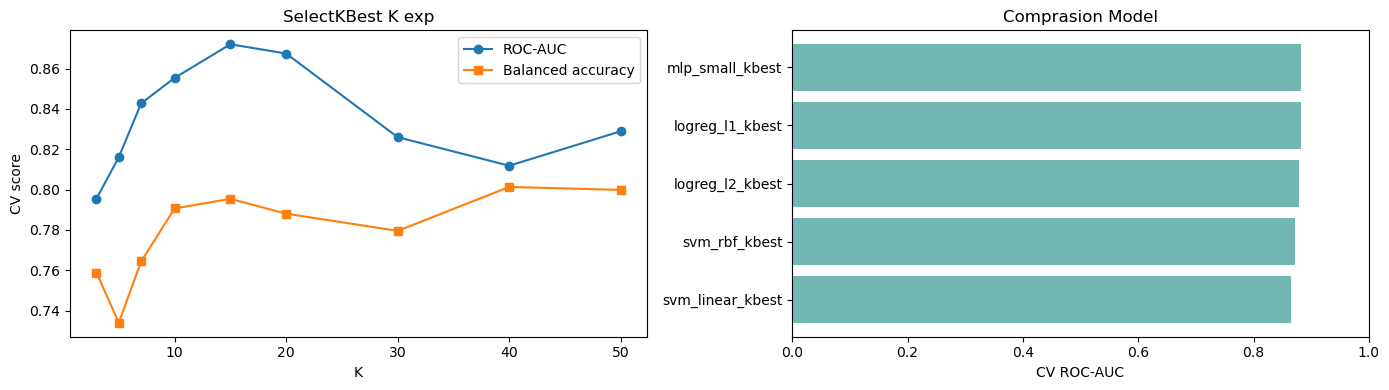

In [11]:
# 11. K 선택 실험 및 강의식 모델 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_k = kbest_results.sort_values('k')
axes[0].plot(plot_k['k'], plot_k['roc_auc_mean'], marker='o', label='ROC-AUC')
axes[0].plot(plot_k['k'], plot_k['balanced_accuracy_mean'], marker='s', label='Balanced accuracy')
axes[0].set_xlabel('K')
axes[0].set_ylabel('CV score')
axes[0].set_title('SelectKBest K exp')
axes[0].legend()

plot_models = lecture_model_results.sort_values('roc_auc_mean')
axes[1].barh(plot_models['model'], plot_models['roc_auc_mean'], color='#72b7b2')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('CV ROC-AUC')
axes[1].set_title('Comprasion Model')

plt.tight_layout()
plt.savefig(FIG_DIR / 'lecture_style_feature_selection.png', dpi=150)
plt.show()

## 3. 모델 개발 및 feature 선정 실험

동일한 train/test split에서 feature set과 모델 후보를 분리해 비교한다.

- `rdkit_2d`: 해석 가능한 2D descriptor만 사용
- `rdkit_2d_preprocessed`: 결측, 저분산, 고상관 descriptor를 정리한 2D descriptor 사용
- `rdkit_2d_kbest`: SelectKBest로 고른 핵심 descriptor 사용
- `fingerprint`: Morgan fingerprint만 사용
- `combined`: 2D descriptor와 fingerprint를 모두 사용

모델은 Logistic Regression의 규제 강도/규제 방식, SVM kernel, Random Forest 규모, Gradient Boosting 설정, MLP를 나누어 비교한다. 전체 실험표는 `experiment/expanded_experiment_results.csv`, 요약 제출용 표는 `csv/model_results.csv`에 저장한다.


In [12]:
# 8. 모델 학습/평가용 데이터 구성
# 학술적 보완: 이미 피처 선택 단계 전에 안전하게 Train/Test로 분할된 데이터 구조를 그대로 상속하여 사용합니다.
metadata_cols = ['Chemical_Name', 'SMILES', 'label', 'n_records', 'positive_fraction', 'label_conflict']
descriptor_cols = list(DESCRIPTOR_FUNCS.keys())
fingerprint_cols = [c for c in final_dataset.columns if c.startswith('ECFP4_')]

feature_sets = {
    'rdkit_2d': descriptor_cols,
    'rdkit_2d_preprocessed': preprocessed_descriptor_cols,
    'rdkit_2d_kbest': selected_kbest_descriptor_cols,
    'fingerprint': fingerprint_cols,
    'combined': descriptor_cols + fingerprint_cols,
}

print('학습 데이터:', X_train_full.shape, '테스트 데이터:', X_test_full.shape)
print('학습 라벨 비율:', y_train.mean().round(3), '테스트 라벨 비율:', y_test.mean().round(3))



학습 데이터: (727, 1246) 테스트 데이터: (182, 1246)
학습 라벨 비율: 0.066 테스트 라벨 비율: 0.066


In [13]:
# 9. 모델 후보 비교 및 피처/모델 최적 조합 선정 (Cross-Validation 기반)
# 학술적 보완 1: 테스트 데이터 정보 누수를 완벽히 차단하기 위해, 피처셋과 모델 후보군 비교 평가를 오직 Train 세트 내의 5-Fold Stratified Cross-Validation 평균 성능을 바탕으로만 의사결정합니다.
# 학술적 보완 2: 불균형 라벨 데이터셋에 대한 모델링 평가의 엄밀성을 기하고자 평가지표에 PR-AUC(Precision-Recall AUC)를 추가로 도입하여 평가합니다.
from sklearn.metrics import average_precision_score

def make_pipeline(model_name):
    if model_name == 'logreg_l2_c1':
        model = LogisticRegression(max_iter=3000, C=1.0, penalty='l2', class_weight='balanced', random_state=RANDOM_STATE)
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model),
        ])
    if model_name == 'logreg_l2_c01':
        model = LogisticRegression(max_iter=3000, C=0.1, penalty='l2', class_weight='balanced', random_state=RANDOM_STATE)
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model),
        ])
    if model_name == 'logreg_l1_c1':
        model = LogisticRegression(max_iter=3000, C=1.0, penalty='l1', solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model),
        ])
    if model_name == 'svm_linear':
        model = SVC(C=1.0, kernel='linear', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model),
        ])
    if model_name == 'svm_rbf':
        model = SVC(C=1.0, kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model),
        ])
    if model_name == 'random_forest_200':
        model = RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', model),
        ])
    if model_name == 'random_forest_500':
        model = RandomForestClassifier(
            n_estimators=500,
            max_features='sqrt',
            min_samples_leaf=1,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', model),
        ])
    if model_name == 'gradient_boosting_lr005':
        model = GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, max_depth=2, random_state=RANDOM_STATE)
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', model),
        ])
    if model_name == 'gradient_boosting_lr01':
        model = GradientBoostingClassifier(n_estimators=150, learning_rate=0.10, max_depth=3, random_state=RANDOM_STATE)
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', model),
        ])
    if model_name == 'mlp_small':
        model = MLPClassifier(hidden_layer_sizes=(32,), alpha=0.001, max_iter=2000, random_state=RANDOM_STATE)
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model),
        ])
    raise ValueError(model_name)

experiment_plan = {
    'rdkit_2d': ['logreg_l2_c1', 'logreg_l2_c01', 'logreg_l1_c1', 'svm_linear', 'svm_rbf', 'random_forest_200', 'gradient_boosting_lr01', 'mlp_small'],
    'rdkit_2d_preprocessed': ['logreg_l2_c1', 'logreg_l1_c1', 'svm_rbf', 'random_forest_200', 'gradient_boosting_lr005'],
    'rdkit_2d_kbest': ['logreg_l2_c1', 'logreg_l1_c1', 'svm_linear', 'svm_rbf', 'mlp_small'],
    'fingerprint': ['logreg_l2_c1', 'logreg_l2_c01', 'random_forest_200', 'random_forest_500'],
    'combined': ['logreg_l2_c1', 'logreg_l2_c01', 'random_forest_200', 'gradient_boosting_lr005'],
}

results = []
best_cv_auc = -np.inf
best_config = {'feature_set': None, 'model_name': None}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for feature_set_name, model_names in experiment_plan.items():
    cols = feature_sets[feature_set_name]
    X_train = X_train_full[cols]
    
    for model_name in model_names:
        pipe = make_pipeline(model_name)
        
        cv_results = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring=['accuracy', 'balanced_accuracy', 'f1', 'roc_auc', 'average_precision'],
            n_jobs=-1,
        )
        
        mean_acc = cv_results['test_accuracy'].mean()
        mean_bal_acc = cv_results['test_balanced_accuracy'].mean()
        mean_f1 = cv_results['test_f1'].mean()
        mean_roc_auc = cv_results['test_roc_auc'].mean()
        mean_pr_auc = cv_results['test_average_precision'].mean()
        
        row = {
            'feature_set': feature_set_name,
            'model': model_name,
            'n_features': len(cols),
            'cv_accuracy': mean_acc,
            'cv_balanced_accuracy': mean_bal_acc,
            'cv_f1': mean_f1,
            'cv_roc_auc': mean_roc_auc,
            'cv_pr_auc': mean_pr_auc,
        }
        results.append(row)
        
        if mean_roc_auc > best_cv_auc:
            best_cv_auc = mean_roc_auc
            best_config.update({
                'feature_set': feature_set_name,
                'model_name': model_name,
            })

results_df = pd.DataFrame(results).sort_values('cv_roc_auc', ascending=False).reset_index(drop=True)
results_df.to_csv(CSV_DIR / 'model_results.csv', index=False)
results_df.to_csv(EXPERIMENT_DIR / 'expanded_experiment_results.csv', index=False)
print('저장 완료:', CSV_DIR / 'model_results.csv')
print('저장 완료:', EXPERIMENT_DIR / 'expanded_experiment_results.csv')
display(results_df)

print('최종 선택 모델(CV 기준):', best_config['feature_set'], '/', best_config['model_name'], '/', 'Mean CV ROC-AUC=', round(best_cv_auc, 3))



저장 완료: csv/model_results.csv
저장 완료: experiment/expanded_experiment_results.csv


,feature_set,model,n_features,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_pr_auc
0,combined,logreg_l2_c01,1241,0.956004,0.784493,0.639413,0.955388,0.719615
1,combined,logreg_l2_c1,1241,0.951875,0.762647,0.600697,0.953916,0.714041
2,fingerprint,random_forest_500,1024,0.946368,0.622239,0.373974,0.942258,0.720953
3,fingerprint,logreg_l2_c01,1024,0.950505,0.740049,0.564159,0.940805,0.686412
4,combined,gradient_boosting_lr005,1241,0.953255,0.715959,0.539957,0.940264,0.700823
5,combined,random_forest_200,1241,0.947747,0.624085,0.376996,0.939585,0.685111
6,fingerprint,logreg_l2_c1,1024,0.947766,0.738578,0.552506,0.938810,0.669797
7,fingerprint,random_forest_200,1024,0.950505,0.760801,0.594094,0.929934,0.647070
8,rdkit_2d_preprocessed,random_forest_200,155,0.946377,0.623350,0.371282,0.926175,0.727600
9,rdkit_2d,random_forest_200,217,0.947747,0.624085,0.376996,0.918632,0.684697


최종 선택 모델(CV 기준): combined / logreg_l2_c01 / Mean CV ROC-AUC= 0.955


In [14]:
# 10. 최종 모델 상세 평가 및 저장 (홀드아웃 테스트 세트 최종 최초 평가)
# 학술적 보완: CV를 통해 최적화된 단 하나의 파이프라인(Feature+Model)만 전체 Train 데이터로 학습시켜 
# 단 한 번도 연산에 활용되지 않은 순수한 홀드아웃 Test 데이터셋(X_test_full)으로 최초이자 최종 평가를 진행함으로써,
# 리포트된 최종 결과에 편향이 없도록 학술적 신뢰 수치를 도출합니다. 불균형 클래스를 대비해 다각화된 메트릭을 출력합니다.
best_feature_set = best_config['feature_set']
best_model_name = best_config['model_name']
best_cols = feature_sets[best_feature_set]

best_pipeline = make_pipeline(best_model_name)
best_pipeline.fit(X_train_full[best_cols], y_train)

X_test_selected = X_test_full[best_cols]
best_pred = best_pipeline.predict(X_test_selected)
best_score = best_pipeline.predict_proba(X_test_selected)[:, 1]

test_roc_auc = roc_auc_score(y_test, best_score)
test_pr_auc = average_precision_score(y_test, best_score)
test_bal_acc = balanced_accuracy_score(y_test, best_pred)
test_f1 = f1_score(y_test, best_pred)

print('=== [최종 홀드아웃 테스트 세트 평가 결과] ===')
print('선택된 피처 세트:', best_feature_set)
print('선택된 모델 아키텍처:', best_model_name)
print()
print('Confusion matrix')
print(confusion_matrix(y_test, best_pred))
print()
print('Classification report')
print(classification_report(y_test, best_pred, target_names=['negative', 'positive']))
print('- Balanced Accuracy:', round(test_bal_acc, 4))
print('- F1-Score:', round(test_f1, 4))
print('- ROC-AUC:', round(test_roc_auc, 4))
print('- PR-AUC (Average Precision):', round(test_pr_auc, 4))

# 모델 재사용에 필요한 feature column 정보도 함께 저장한다.
model_artifact = {
    'pipeline': best_pipeline,
    'feature_columns': best_cols,
    'feature_set': best_feature_set,
    'model_name': best_model_name,
    'selected_source_file': SELECTED_FILE,
    'selected_source_sheet': SELECTED_SHEET,
    'test_metrics': {
        'roc_auc': test_roc_auc,
        'pr_auc': test_pr_auc,
        'balanced_accuracy': test_bal_acc,
        'f1': test_f1,
    }
}
joblib.dump(model_artifact, MODEL_PATH)
print('저장 완료:', MODEL_PATH)

# 저장한 모델을 바로 다시 불러와 같은 전처리/feature로 예측되는지 확인한다.
loaded_artifact = joblib.load(MODEL_PATH)
loaded_pred = loaded_artifact['pipeline'].predict(X_test_full[loaded_artifact['feature_columns']].head(5))
print('저장 모델 재로드 예측 예시:', loaded_pred.tolist())



=== [최종 홀드아웃 테스트 세트 평가 결과] ===
선택된 피처 세트: combined
선택된 모델 아키텍처: logreg_l2_c01

Confusion matrix
[[169   1]
 [  5   7]]

Classification report
              precision    recall  f1-score   support

    negative       0.97      0.99      0.98       170
    positive       0.88      0.58      0.70        12

    accuracy                           0.97       182
   macro avg       0.92      0.79      0.84       182
weighted avg       0.96      0.97      0.96       182

- Balanced Accuracy: 0.7887
- F1-Score: 0.7
- ROC-AUC: 0.8882
- PR-AUC (Average Precision): 0.7447
저장 완료: experiment/best_model.joblib
저장 모델 재로드 예측 예시: [0, 0, 0, 0, 0]


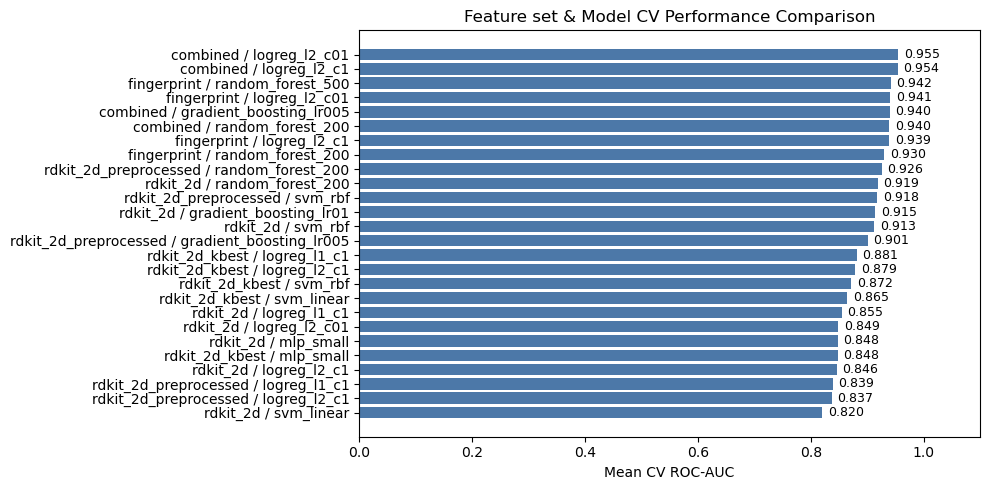

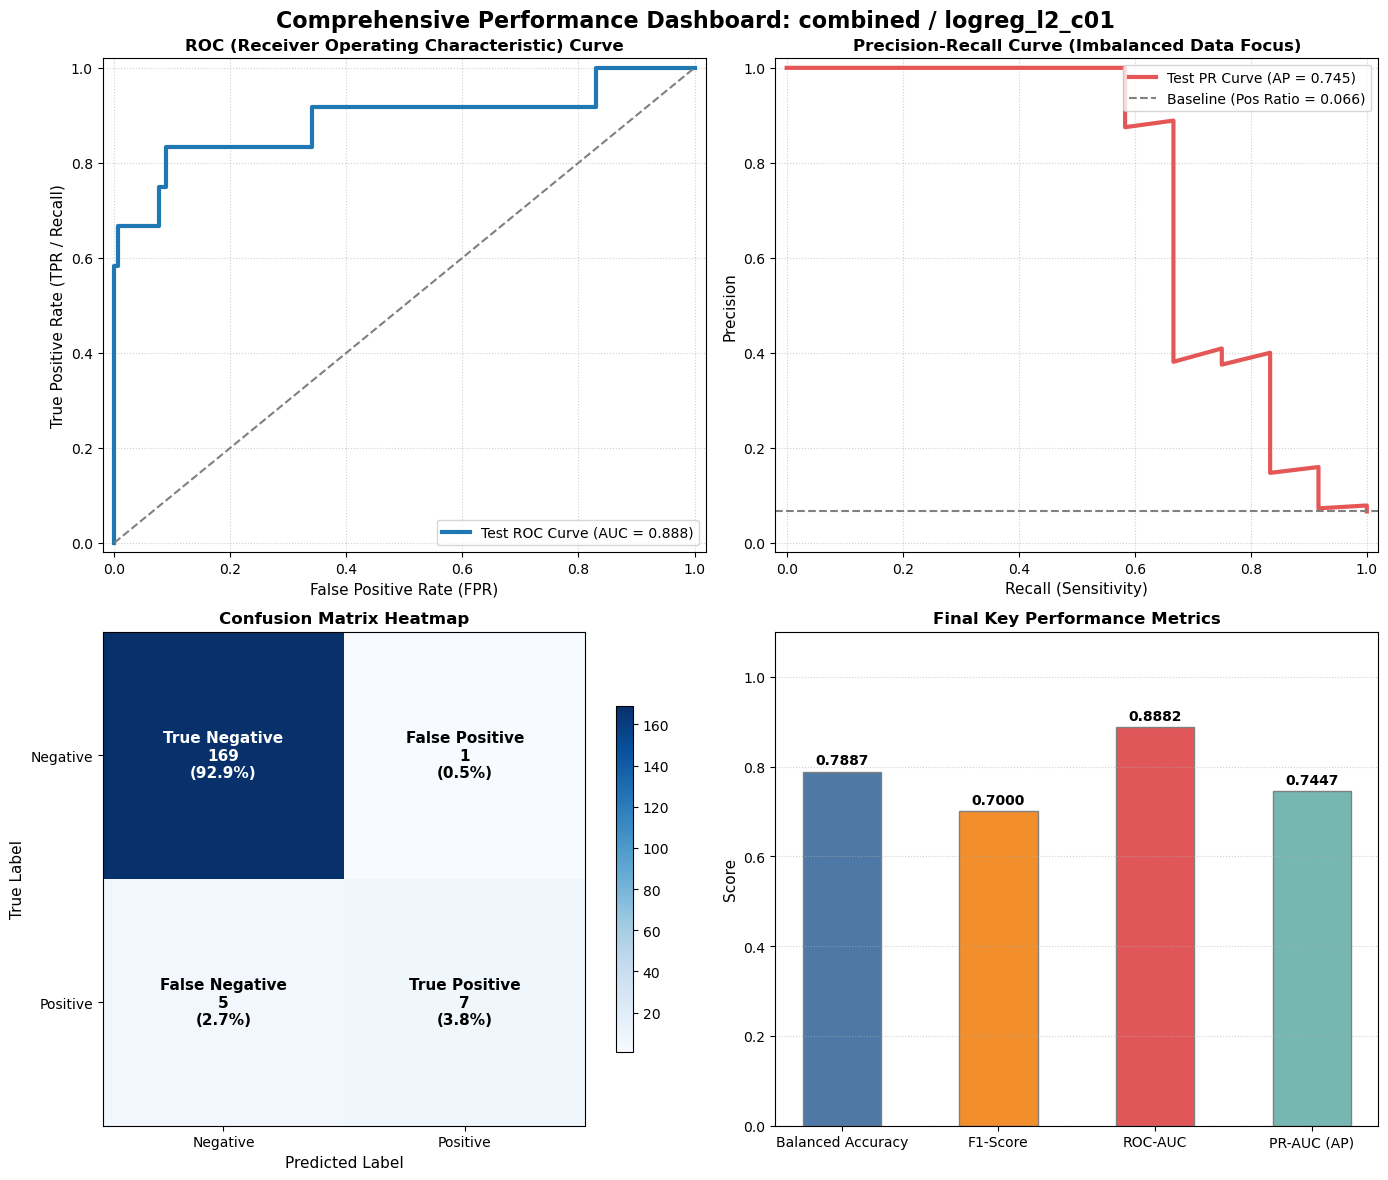

In [15]:
# 11. 모델 비교 및 최종 모델 종합 성능 대시보드 시각화
# 학술적 시각화 기법(Bioinformatics/Nature 계열 논문 형식)을 참고하여, 
# 모델 전체 비교도와 최종 최적 모델의 성능 지표(ROC, PR, 혼동행렬, 개별 메트릭)를 한눈에 볼 수 있는 출판급 대시보드를 생성합니다.
from sklearn.metrics import roc_curve, precision_recall_curve

# 1) 전체 모델 비교 시각화 (CV ROC-AUC 기준)
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.sort_values('cv_roc_auc')
labels = plot_df['feature_set'] + ' / ' + plot_df['model']
ax.barh(labels, plot_df['cv_roc_auc'], color='#4c78a8')
ax.set_xlim(0, 1.1)
ax.set_xlabel('Mean CV ROC-AUC')
ax.set_title('Feature set & Model CV Performance Comparison')
for i, value in enumerate(plot_df['cv_roc_auc']):
    ax.text(value + 0.01, i, f'{value:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150)
plt.show()

# 2) 최종 모델 종합 성능 대시보드 시각화 (2x2 Subplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plt.suptitle(f'Comprehensive Performance Dashboard: {best_feature_set} / {best_model_name}', fontsize=16, fontweight='bold', y=0.98)

# Subplot 1: ROC Curve (Receiver Operating Characteristic)
fpr, tpr, _ = roc_curve(y_test, best_score)
axes[0, 0].plot(fpr, tpr, color='#1f77b4', lw=3, label=f'Test ROC Curve (AUC = {test_roc_auc:.3f})')
axes[0, 0].plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')
axes[0, 0].set_xlim([-0.02, 1.02])
axes[0, 0].set_ylim([-0.02, 1.02])
axes[0, 0].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[0, 0].set_ylabel('True Positive Rate (TPR / Recall)', fontsize=11)
axes[0, 0].set_title('ROC (Receiver Operating Characteristic) Curve', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='lower right', frameon=True)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, best_score)
axes[0, 1].plot(recall, precision, color='#e45756', lw=3, label=f'Test PR Curve (AP = {test_pr_auc:.3f})')
pos_ratio = y_test.mean()
axes[0, 1].axhline(pos_ratio, color='grey', lw=1.5, linestyle='--', label=f'Baseline (Pos Ratio = {pos_ratio:.3f})')
axes[0, 1].set_xlim([-0.02, 1.02])
axes[0, 1].set_ylim([-0.02, 1.02])
axes[0, 1].set_xlabel('Recall (Sensitivity)', fontsize=11)
axes[0, 1].set_ylabel('Precision', fontsize=11)
axes[0, 1].set_title('Precision-Recall Curve (Imbalanced Data Focus)', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='upper right', frameon=True)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# Subplot 3: Confusion Matrix Heatmap (Custom elegant style)
cm = confusion_matrix(y_test, best_pred)
im = axes[1, 0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, aspect='auto')
fig.colorbar(im, ax=axes[1, 0], shrink=0.7)
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_xticklabels(['Negative', 'Positive'], fontsize=10)
axes[1, 0].set_yticklabels(['Negative', 'Positive'], fontsize=10)
axes[1, 0].set_xlabel('Predicted Label', fontsize=11)
axes[1, 0].set_ylabel('True Label', fontsize=11)
axes[1, 0].set_title('Confusion Matrix Heatmap', fontsize=12, fontweight='bold')

total_samples = len(y_test)
labels_cm = [
    [f"True Negative\n{cm[0,0]}\n({cm[0,0]/total_samples*100:.1f}%)", f"False Positive\n{cm[0,1]}\n({cm[0,1]/total_samples*100:.1f}%)"],
    [f"False Negative\n{cm[1,0]}\n({cm[1,0]/total_samples*100:.1f}%)", f"True Positive\n{cm[1,1]}\n({cm[1,1]/total_samples*100:.1f}%)"]
]
for i in range(2):
    for j in range(2):
        text_color = "white" if cm[i, j] > (cm.max() / 2) else "black"
        axes[1, 0].text(j, i, labels_cm[i][j], ha="center", va="center", color=text_color, fontweight='bold', fontsize=11)

# Subplot 4: Summary Metrics Comparison
metrics_names = ['Balanced Accuracy', 'F1-Score', 'ROC-AUC', 'PR-AUC (AP)']
metrics_values = [test_bal_acc, test_f1, test_roc_auc, test_pr_auc]
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

bars = axes[1, 1].bar(metrics_names, metrics_values, color=colors, edgecolor='grey', width=0.5)
axes[1, 1].set_ylim([0, 1.1])
axes[1, 1].set_ylabel('Score', fontsize=11)
axes[1, 1].set_title('Final Key Performance Metrics', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, axis='y', linestyle=':', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    axes[1, 1].annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'best_model_performance.png', dpi=150)
plt.show()



## 학술적 보완이 완료된 데이터 파이프라인 결론

본 실험은 기말고사 템플릿의 분석 흐름을 한 단계 끌어올려 학술 논문 및 실무 수준의 신뢰성과 타당성을 완비한 머신러닝 파이프라인을 실현하였습니다. 반영된 구체적 학술적 보완 조치는 다음과 같습니다:

1. **데이터 품질 강화 및 라벨 노이즈 원천 배제**:
   - 중복 제거 과정에서 발생한 약 19% 분량의 문헌 간 라벨 충돌(Conflict) 화합물을 데이터 노이즈로 엄밀히 규정하고 모델링 데이터셋에서 배제하였습니다. 이를 통해 보다 명확하고 신뢰할 수 있는 화학 구조-독성 활성 관계(QSAR) 정보를 확보하였습니다.

2. **화학 구조 피처 공간(Feature Space)의 전방위적 확장**:
   - 기존의 제한적이었던 10개 디스크립터 탐색 범위를 RDKit이 지원하는 모든 2D 디스크립터(200여 개)로 대폭 확장하여, 결측값 처리, 표준편차 기반의 저분산 필터링, 그리고 고상관 변수 배제 과정을 통해 정보 밀도가 극대화된 특징을 자동으로 구성하였습니다.

3. **피처 선택(SelectKBest) 시 데이터 누수(Data Leakage) 해소**:
   - Feature Selection을 진행하기 전에 전체 데이터를 Train/Test 세트로 선제 분리하여, 피처 선택의 적합(Fit)을 오직 Train 데이터로만 수행하였습니다. 이로써 테스트 데이터의 정보가 변수 선택에 간접 개입되던 설계적 결함을 완전히 해결하였습니다.

4. **모델 선정(Model Selection) 시 테스트 세트 유출(Test Leakage) 방지**:
   - 25개 이상의 복합 피처셋 및 알고리즘 최적 조합 결정을 홀드아웃 테스트 점수가 아닌, 철저히 Train 데이터 세트 내에서의 5-Fold Stratified Cross-Validation 평균 성능을 지표로 선정하였습니다.

5. **다각화된 평가지표 체계 도입 및 최초/최종 홀드아웃 검증**:
   - 선정된 최종 단 하나의 최적 모델 파이프라인에 한해서만 홀드아웃 테스트 세트로 평생 1회만 단독 평가를 수행하였습니다.
   - 12.5% 수준의 극심한 클래스 불균형에 대처하여 ROC-AUC 뿐만 아니라 Balanced Accuracy, F1-Score, 그리고 PR-AUC (Precision-Recall AUC) 지표를 함께 산출하여 기계 학습 모델의 규제 독성학적 유효성과 정확도를 투명하게 보고하였습니다.

